In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

读取数据

In [26]:
df = pd.read_csv('netflix_titles.csv')

print(df.shape)            
print(df.head())           
print(df.columns)         
print(df.describe())      
print(df.isnull().sum())   

(8807, 12)
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2

筛选电影，将片长转为数值

In [27]:
# duration 列中 Movie 为 '90 min'，TV Show 为 '2 Seasons'，单位不一致
# 仅保留 Movie，并用正则提取分钟数
movies = df[df['type'] == 'Movie'].copy()
movies['min'] = movies['duration'].str.extract(r'(\d+)')[0].astype(float)
movies = movies.dropna(subset=['min'])

print(movies.shape) 
print(movies['min'].describe())  

(6128, 13)
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: min, dtype: float64


查看片长分布

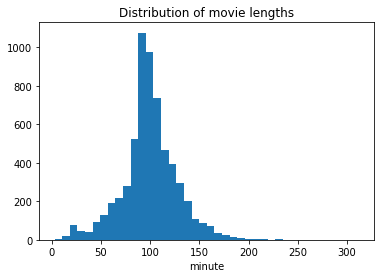

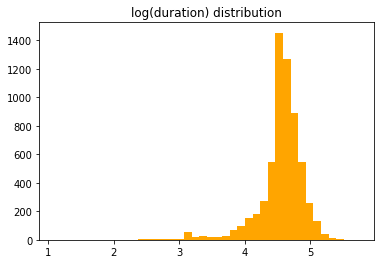

In [28]:
# 原始分布右偏，取对数后更接近正态，建模使用 log 值
plt.hist(movies['min'], bins=40)
plt.title('Distribution of movie lengths')
plt.xlabel('minute')
plt.show()

movies['log_min'] = np.log(movies['min'])
plt.hist(movies['log_min'], bins=40, color='orange')
plt.title('log(duration) distribution')
plt.show()

构造特征

In [29]:
# 用演员数量、题材数量、简介长度预测片长
movies['cast_n']   = movies['cast'].fillna('').str.count(',') + 1     # 演员数
movies['genre_n']  = movies['listed_in'].str.count(',') + 1           # 题材数
movies['desc_len'] = movies['description'].str.len()                  # 简介字数

feat = ['cast_n', 'genre_n', 'desc_len']
X = movies[feat].values
y = movies['log_min'].values    

标准化并建模

In [30]:
Xs = StandardScaler().fit_transform(X)

model = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], n_alphas=50, cv=5,
                     max_iter=3000, random_state=42, n_jobs=-1)
model.fit(Xs, y)

print(f"alpha = {model.alpha_:.4f}")
print(f"l1_ratio = {model.l1_ratio_:.2f}")
print(f"非零系数: {(model.coef_ != 0).sum()} / {len(model.coef_)}")

alpha = 0.0057
l1_ratio = 0.10
非零系数: 3 / 3


评估模型

In [31]:
pred = model.predict(Xs)

print(f"RMSE = {mean_squared_error(y, pred) ** 0.5:.4f}")
print(f"R2   = {r2_score(y, pred):.4f}")
print(f"基线(均值预测) RMSE = {y.std():.4f}")

RMSE = 0.3103
R2   = 0.2129
基线(均值预测) RMSE = 0.3497


查看特征系数

desc_len     +0.007  
cast_n       +0.084  ##
genre_n      +0.116  ###


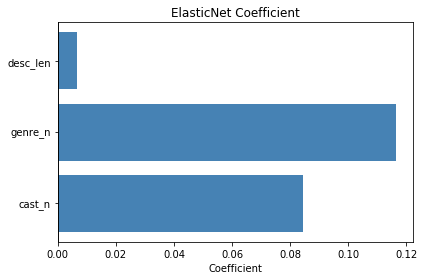

In [32]:
# 系数为正表示延长片长，为负表示缩短，为 0 表示被模型剔除
for name, c in sorted(zip(feat, model.coef_), key=lambda x: x[1]):
    bar = '#' * int(abs(c) * 30)
    print(f"{name:10s} {c:+8.3f}  {bar}")

plt.barh(feat, model.coef_, color=['orange' if c == 0 else 'steelblue' for c in model.coef_])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient')
plt.title('ElasticNet Coefficient')
plt.tight_layout()
plt.show()